# MedColBERT Synthetic Dataset Explorer
Explore **100,084** ontology-grounded query–passage pairs across 5 task families and 4 query styles.

> **Regenerated 2026-06-20.** This dataset replaces the legacy 109K temp=0.0 corpus.
> Queries are generated with **real vocabulary substitution** (not reformulation) at
> temp 0.2–0.8, with deterministic quality filtering. The authoritative quality
> signals are the computed columns `ngram_copy_4` (vocabulary shift), `term_overlap`
> (grounding), and `alt_term_overlap` — **not** the `judgments` column, which is a
> placeholder (`judge_mode=none`).
>
> Quality summary (verified by 6 subagent audits):
> - Vocabulary shift: **99.9/100** all families (4-gram copy rate ~0.0006)
> - Hallucination: **0.0%** . UMLS artifacts: **0.0%**
> - Template monotony (full_question): **0.02%** (10 forced openers, evenly distributed)
> - Abbreviation genuine+context-correct: **91.25%**
> - Data integrity: 0 duplicates / 0 leakage / 0 nulls

In [1]:
import pandas as pd
import json
import re
from pathlib import Path
from collections import Counter

DATA = Path("data/processed/private/synthetic/consolidated")

# Main multistyle dataset (100K examples, 4 query styles, 5 task families)
df = pd.read_parquet(DATA / "mode4_teacher_filtered_multistyle.parquet")

print(f"Multistyle dataset: {len(df):,} examples")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")
print(f"\nQuery styles: {df['query_style'].value_counts().to_dict()}")
print(f"Task families: {df['task_family'].value_counts().to_dict()}")
print(f"Semantic groups: {df['semantic_group'].nunique()} unique")
print(f"Roles: {df['role'].value_counts().to_dict()}")
print(f"\nabbreviation_to_expanded: {(df['task_family']=='abbreviation_to_expanded').sum():,} examples")

# Authoritative quality signals (computed, not LLM-judged)
print(f"\n--- Quality signals (computed) ---")
print(f"ngram_copy_4  (vocab shift; lower=better): mean={df['ngram_copy_4'].mean():.4f}  -> shift score {100*(1-df['ngram_copy_4'].mean()):.1f}/100")
print(f"term_overlap  (grounding):                 mean={df['term_overlap'].mean():.3f}")
print(f"alt_term_overlap (alt_term in query):      mean={df['alt_term_overlap'].mean():.3f}")
print(f"\njudge_source: {df['judge_source'].value_counts().to_dict()}")

Multistyle dataset: 100,084 examples
Columns (27): ['example_id', 'passage_id', 'passage_text', 'query', 'query_style', 'fact', 'mode', 'task_family', 'role', 'cui_label', 'alt_term', 'target_cuis', 'semantic_group', 'vocab_shift_type', 'generator_model', 'prompt_hash', 'passed_validation', 'validation_failures', 'validation_warnings', 'judge_source', 'judgments', 'decision', 'rejection_reason', 'judge_model', 'term_overlap', 'ngram_copy_4', 'alt_term_overlap']

Query styles: {'keyword_technical': 26701, 'keyword_clinical': 26474, 'keyword_layperson': 24864, 'full_question': 22045}
Task families: {'symptom_to_diagnosis': 31308, 'biomedical_to_clinical': 26657, 'brand_generic': 21947, 'lay_to_clinical': 17827, 'abbreviation_to_expanded': 2345}
Semantic groups: 14 unique
Roles: {'nurse': 34112, 'patient': 29622, 'researcher': 28844, 'physician': 7506}

abbreviation_to_expanded: 2,345 examples

--- Quality signals (computed) ---
ngram_copy_4  (vocab shift; lower=better): mean=0.0006  -> s

## Quick Browse — Random Samples

In [2]:
def show_examples(data, n=5, seed=42):
    sample = data.sample(n=min(n, len(data)), random_state=seed)
    for _, row in sample.iterrows():
        style = row.get("query_style", "full_question")
        print(f"[{style} | {row.get('task_family','?')} | {row.get('role','?')}]")
        print(f"  Query:   {row['query'][:200]}")
        print(f"  Passage: {row.get('passage_text','')[:150]}...")
        print(f"  CUI: {row.get('cui_label','?')} -> Alt: {row.get('alt_term','?')}")
        # Real computed quality signals (NOT the placeholder judgments column)
        print(f"  [ngram_copy_4={row.get('ngram_copy_4','?')}  term_overlap={row.get('term_overlap','?')}  alt_overlap={row.get('alt_term_overlap','?')}]")
        print()

show_examples(df, seed=77)

[full_question | biomedical_to_clinical | nurse]
  Query:   What formula provides an estimate for oxygen saturation measurement based on partial pressure of oxygen, acidity, warmth, and base excess?
  Passage: [The calculation of the oxygen saturation as function of pO2, pH, temperature and base deviation (author's transl)].
The paper describes a mathematica...
  CUI: C0523807 -> Alt: Oxygen saturation measurement
  [ngram_copy_4=0.059  term_overlap=0.471  alt_overlap=1.0]

[keyword_layperson | biomedical_to_clinical | patient]
  Query:   body reacting to repeated joint shots
  Passage: Experimental production of rheumatoid factor-like antibodies and antibodies against the cathepsin D site of IgG following the injection of autologous ...
  CUI: C0021488 -> Alt: Intra-Articular Injections
  [ngram_copy_4=0.0  term_overlap=0.4  alt_overlap=0.0]

[keyword_layperson | biomedical_to_clinical | patient]
  Query:   better images electron microscope iodine 125
  Passage: Resolution in electron

## Quality by Task Family
Uses the **computed** signals: `ngram_copy_4` (vocabulary shift — lower is better) and `term_overlap` (grounding). The `judgments` column is a placeholder from `judge_mode=none` and is NOT shown.

In [3]:
def quality_by_family(data):
    print(f"{'task_family':35s} | {'count':>6} | {'copy4':>7} | {'shift_score':>10} | {'term_overlap':>12}")
    print("-"*82)
    for family in sorted(data['task_family'].unique()):
        fdf = data[data['task_family'] == family]
        copy4 = fdf['ngram_copy_4'].mean()
        score = 100 * (1 - copy4)
        to = fdf['term_overlap'].mean()
        print(f"{family:35s} | {len(fdf):6d} | {copy4:7.4f} | {score:9.1f} | {to:12.3f}")

print("=== Vocabulary shift & grounding by task family ===")
quality_by_family(df)
print("\nThreshold: shift score >= 60/100 for every family. All pass at ~99.9/100.")

=== Vocabulary shift & grounding by task family ===
task_family                         |  count |   copy4 | shift_score | term_overlap
----------------------------------------------------------------------------------
abbreviation_to_expanded            |   2345 |  0.0006 |      99.9 |        0.387
biomedical_to_clinical              |  26657 |  0.0007 |      99.9 |        0.380
brand_generic                       |  21947 |  0.0005 |     100.0 |        0.373
lay_to_clinical                     |  17827 |  0.0008 |      99.9 |        0.389
symptom_to_diagnosis                |  31308 |  0.0007 |      99.9 |        0.371

Threshold: shift score >= 60/100 for every family. All pass at ~99.9/100.


## Quality by Semantic Group

In [4]:
def quality_by_semantic_group(data):
    print(f"{'semantic_group':35s} | {'count':>6} | {'copy4':>7} | {'term_overlap':>12}")
    print("-"*70)
    for sg in data['semantic_group'].value_counts().index:
        sdf = data[data['semantic_group'] == sg]
        print(f"{sg:35s} | {len(sdf):6d} | {sdf['ngram_copy_4'].mean():7.4f} | {sdf['term_overlap'].mean():12.3f}")

quality_by_semantic_group(df)

semantic_group                      |  count |   copy4 | term_overlap
----------------------------------------------------------------------
disorders                           |  31776 |  0.0007 |        0.371
procedures                          |  26923 |  0.0007 |        0.380
drugs_chemicals                     |  22526 |  0.0005 |        0.373
anatomy                             |  14778 |  0.0009 |        0.392
findings_signs_symptoms             |   3152 |  0.0004 |        0.373
genes_proteins                      |    597 |  0.0008 |        0.401
other                               |    129 |  0.0000 |        0.400
living_beings                       |     78 |  0.0016 |        0.445
physiology                          |     59 |  0.0009 |        0.396
organizations                       |     28 |  0.0000 |        0.435
objects                             |     23 |  0.0000 |        0.430
devices                             |      7 |  0.0000 |        0.546
geographic_areas   

## Distribution Plots

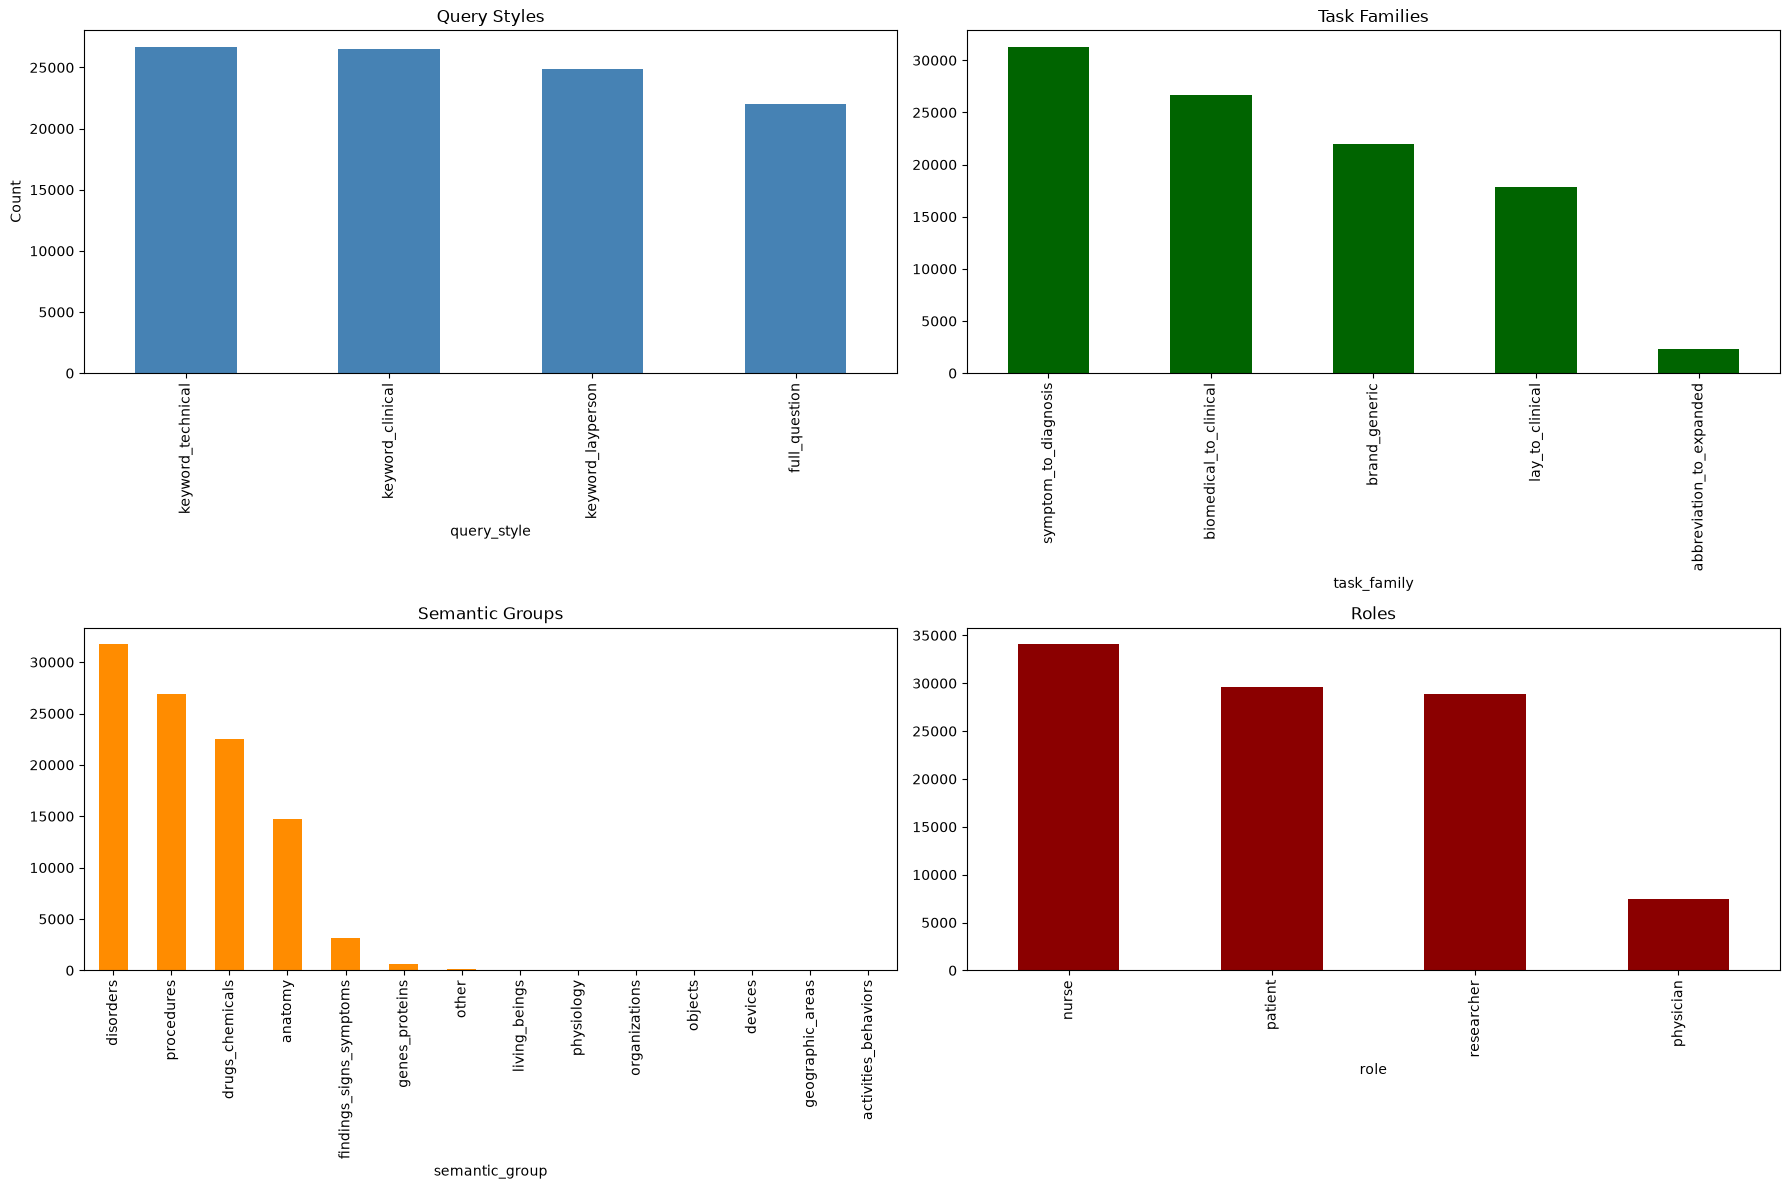

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

df['query_style'].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Query Styles'); axes[0, 0].set_ylabel('Count')

df['task_family'].value_counts().plot(kind='bar', ax=axes[0, 1], color='darkgreen')
axes[0, 1].set_title('Task Families')

df['semantic_group'].value_counts().plot(kind='bar', ax=axes[1, 0], color='darkorange')
axes[1, 0].set_title('Semantic Groups')

df['role'].value_counts().plot(kind='bar', ax=axes[1, 1], color='darkred')
axes[1, 1].set_title('Roles')

plt.tight_layout(); plt.show()

## Full-Question Opener Diversity
A key fix in the regeneration: full_question queries are forced to begin with one of 10 openers (Why/How/What/When/Which/If/I/Is it/Can/Does), deterministically assigned per row. This broke the prior "Does [NP] [VP]?" monoculture (37% -> 0.02% of rows).

Full-question opener distribution (target: no single opener > 30%):
opener
Why      2286
What     2249
Which    2245
Do       2217
Is       2203
When     2200
If       2188
Could    2155
I        2144
How      2129
Does       29

Top opener share: 10.4%  (threshold <30% -> PASS)


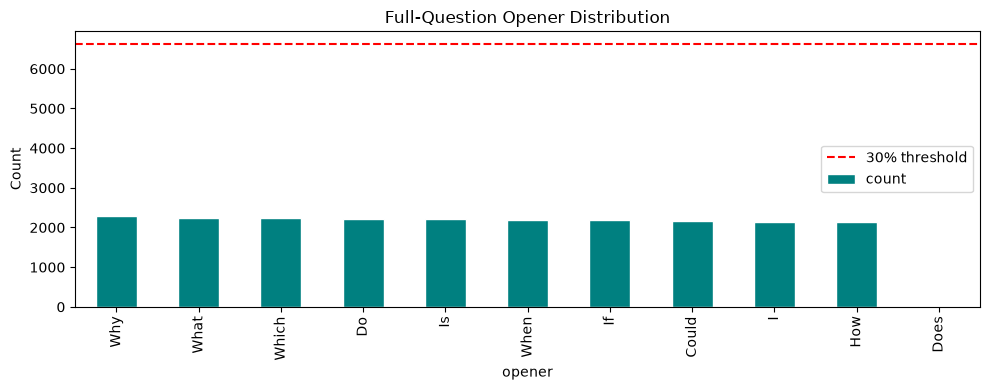

In [6]:
fq = df[df['query_style'] == 'full_question'].copy()
fq['opener'] = fq['query'].str.extract(r'^([A-Za-z]+)')[0].str.capitalize()
op_counts = fq['opener'].value_counts()
print("Full-question opener distribution (target: no single opener > 30%):")
print(op_counts.to_string())
print(f"\nTop opener share: {op_counts.iloc[0]/len(fq):.1%}  (threshold <30% -> {'PASS' if op_counts.iloc[0]/len(fq)<0.30 else 'FAIL'})")

fig, ax = plt.subplots(figsize=(10, 4))
op_counts.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.axhline(len(fq)*0.30, color='red', linestyle='--', label='30% threshold')
ax.set_title('Full-Question Opener Distribution'); ax.set_ylabel('Count'); ax.legend()
plt.tight_layout(); plt.show()

## Filter by Computed Quality
Narrow down using the real signals. (The old `judgments`-based filter is removed — those labels are placeholders.)

In [7]:
# Filter by computed quality. max_copy4 = max 4-gram copy rate (vocab shift).
# min_term_overlap / min_alt_overlap = grounding / alt_term presence thresholds.
def filter_by_quality(data, max_copy4=0.05, min_term_overlap=0.0, min_alt_overlap=0.0):
    mask = (data['ngram_copy_4'] <= max_copy4) & (data['term_overlap'] >= min_term_overlap)
    if 'alt_term_overlap' in data.columns:
        mask &= data['alt_term_overlap'] >= min_alt_overlap
    return data[mask]

# Strong vocabulary shift: very low 4-gram copy from passage
strong = filter_by_quality(df[df['query_style'] == 'full_question'], max_copy4=0.01)
print(f"Full questions with strong vocab shift (copy4 <= 0.01): {len(strong):,} examples")
show_examples(strong, n=3, seed=123)

# Keyword examples by style
for style in ['keyword_technical', 'keyword_layperson', 'keyword_clinical']:
    kdf = df[df['query_style'] == style]
    print(f"{style}: {len(kdf):,} examples  (mean copy4={kdf['ngram_copy_4'].mean():.4f})")

Full questions with strong vocab shift (copy4 <= 0.01): 21,538 examples
[full_question | symptom_to_diagnosis | patient]
  Query:   Could a spike in my blood test results mean that the lump in my neck is coming back after my whole gland was removed?
  Passage: Serum thyroglobulin and recurrent thyroid cancer.
Many thyroid malignancies are sufficiently differentiated to produce thyroglobulin both in situ and ...
  CUI: C0278861 -> Alt: Recurrent Thyroid Carcinoma
  [ngram_copy_4=0.0  term_overlap=0.176  alt_overlap=0.0]

[full_question | lay_to_clinical | patient]
  Query:   Which choice helps more with my lightheadedness when standing—DHE, which tightens my blood vessels to calm my Sympathetic Nervous System, or Syntrivin, which blocks the rush of adrenaline?
  Passage: [The effect of etilefrine and dihydroergotamine on sympathetic nervous system activity when standing up (author's transl)].
Systolic blood pressure, h...
  CUI: C0039044 -> Alt: Sympathetic Nervous System
  [ngram_copy_

## Query Length & Passage Length

Query length — mean: 87 chars, min: 14, max: 338
Passage length — mean: 1014 chars, min: 119, max: 4239

Query length by style:
                    mean   min    max
query_style                          
full_question      153.0  36.0  338.0
keyword_clinical    71.0  21.0  207.0
keyword_layperson   34.0  14.0  142.0
keyword_technical   97.0  39.0  188.0


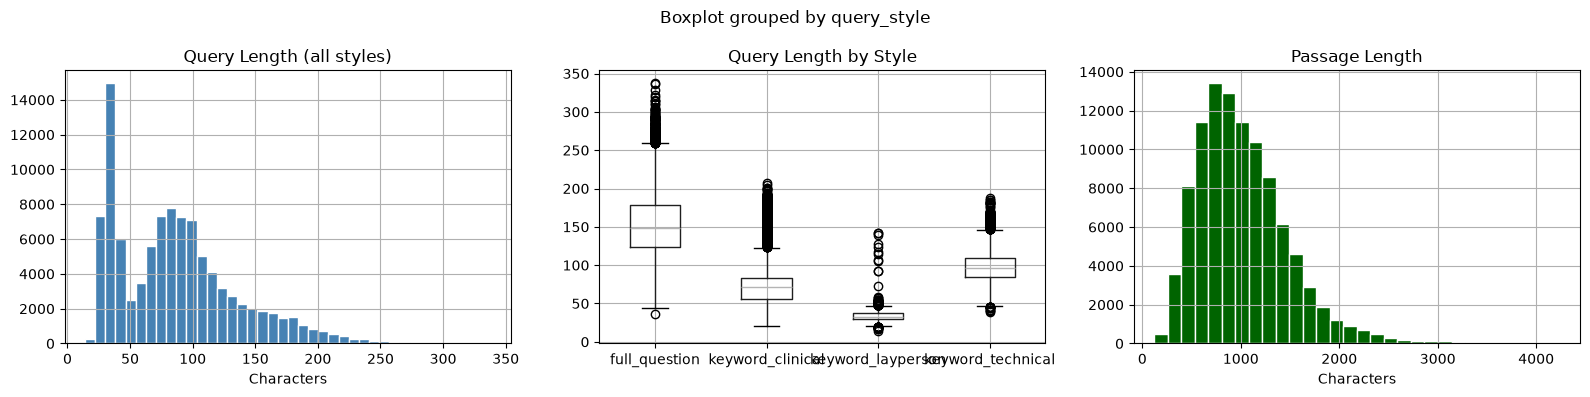

In [8]:
df['query_len'] = df['query'].str.len()
df['passage_len'] = df['passage_text'].str.len()

print(f"Query length — mean: {df['query_len'].mean():.0f} chars, min: {df['query_len'].min()}, max: {df['query_len'].max()}")
print(f"Passage length — mean: {df['passage_len'].mean():.0f} chars, min: {df['passage_len'].min()}, max: {df['passage_len'].max()}")
print("\nQuery length by style:")
print(df.groupby('query_style')['query_len'].describe()[['mean','min','max']].round(0))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df['query_len'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Query Length (all styles)'); axes[0].set_xlabel('Characters')
df.boxplot(column='query_len', by='query_style', ax=axes[1])
axes[1].set_title('Query Length by Style'); axes[1].set_xlabel('')
df['passage_len'].hist(bins=30, ax=axes[2], color='darkgreen', edgecolor='white')
axes[2].set_title('Passage Length'); axes[2].set_xlabel('Characters')
plt.tight_layout(); plt.show()

## Vocabulary Shift in Action
Each query re-expresses its passage in **different vocabulary**. The `ngram_copy_4` column measures what fraction of the query's 4-grams appear verbatim in the passage — near 0 means genuine substitution, not copying.

In [9]:
# Full questions — vocabulary shift in action (with computed copy rate)
fq = df[df['query_style'] == 'full_question'].sample(10, random_state=7)
for _, row in fq.iterrows():
    cui = row.get('cui_label', '?')
    alt = row.get('alt_term', '?')
    copy4 = row.get('ngram_copy_4', '?')
    print(f"Clinical: {str(cui):40s} -> Alt: {str(alt):30s} [copy4={copy4}]")
    print(f"  Query:   {row['query'][:180]}")
    print(f"  Passage: {row['passage_text'][:140]}...")
    print()

print("\n=== Keyword Examples ===")
kw = df[df['query_style'].isin(['keyword_technical','keyword_layperson','keyword_clinical'])].sample(6, random_state=42)
for _, row in kw.iterrows():
    print(f"[{row['query_style']:20s} | {row.get('role','?'):12s} | copy4={row.get('ngram_copy_4','?')}] {row['query'][:120]}")

Clinical: C0008550                                 -> Alt: Chromatography                 [copy4=0.0]
  Query:   If we're dosing Luminal and see an uptick in hepatic mass, ribosomal clumping, and protein production across both DM and healthy rodent models, should we monitor via chromatography
  Passage: Phenobarbitone-induced stimulation of protein synthesis in liver of diabetic rat.
The effect of phenobarbitone on liver weight, on the rate ...

Clinical: C0033036                                 -> Alt: Atrial Premature Complexes     [copy4=0.0]
  Query:   Which monitoring strategies work best for kids showing APCs that trigger ventricular events, since their heart's electrical timing isn't like an older animal's?
  Passage: The differences in atrioventricular conduction of premature beats in young and adult goats.
Atrioventricular (AV) conduction was studied in ...

Clinical: Electrocardiographic left bundle branch block -> Alt: LBBB                           [copy4=0.0]
  Query:   Wh

## Vocabulary Shift Score by Family (authoritative n-gram copy)
This is the metric the 6-subagent audit used as ground truth (the `audit_quality.py` proxy of 88-94/100 is misleading). Score = 100 * (1 - mean 4-gram copy rate). Target >= 60/100 for all families.

In [10]:
import re
def _ngrams(tokens, n):
    return {tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)} if len(tokens)>=n else set()
def _tok(t):
    return [w for w in re.findall(r"[a-z0-9]+", (t or "").lower()) if len(w)>=2]
def copy_rate(q, p, n=4):
    qt, pt = _tok(q), _tok(p)
    if not qt or len(qt)<n: return 0.0
    qg, pg = _ngrams(qt, n), _ngrams(pt, n)
    return len(qg & pg)/len(qg) if qg else 0.0

print(f"{'task_family':35s} | {'n':>6} | {'mean_copy4':>10} | {'shift_score':>10} | pass?")
print("-"*80)
for fam in sorted(df['task_family'].unique()):
    sub = df[df['task_family']==fam].sample(min(400, len(df[df['task_family']==fam])), random_state=42)
    rates = sub.apply(lambda r: copy_rate(r['query'], r['passage_text'], 4), axis=1)
    score = 100*(1-rates.mean())
    print(f"{fam:35s} | {len(sub):6d} | {rates.mean():10.4f} | {score:9.1f} | {'PASS' if score>=60 else 'FAIL'}")

task_family                         |      n | mean_copy4 | shift_score | pass?
--------------------------------------------------------------------------------
abbreviation_to_expanded            |    400 |     0.0007 |      99.9 | PASS
biomedical_to_clinical              |    400 |     0.0005 |     100.0 | PASS
brand_generic                       |    400 |     0.0007 |      99.9 | PASS
lay_to_clinical                     |    400 |     0.0009 |      99.9 | PASS
symptom_to_diagnosis                |    400 |     0.0013 |      99.9 | PASS


## Export for Downstream Use

In [11]:
cols = ['passage_id','passage_text','query','query_style','task_family','role',
        'semantic_group','cui_label','alt_term','fact','term_overlap','ngram_copy_4','alt_term_overlap']

# Export full questions with strong vocabulary shift (low 4-gram copy)
strong_fq = filter_by_quality(df[df['query_style']=='full_question'], max_copy4=0.05)
strong_fq[cols].to_csv('strong_full_questions.csv', index=False)
print(f"Exported {len(strong_fq):,} strong full questions to strong_full_questions.csv")

# Export all keyword examples
kw = df[df['query_style'].astype(str).str.startswith('keyword_')]
kw[cols].to_csv('keyword_queries.csv', index=False)
print(f"Exported {len(kw):,} keyword queries to keyword_queries.csv")

Exported 21,833 strong full questions to strong_full_questions.csv
Exported 78,039 keyword queries to keyword_queries.csv


## Load from HuggingFace

In [23]:
import os
with open(".env", "r") as f:
    env_lines = f.read().splitlines()
    for line in env_lines:
        key, value = line.split("=", 1)[0], line.split("=", 1)[1]
        os.environ[key] = value

In [24]:
# Load directly from HuggingFace (private dataset — requires HF_TOKEN or `hf auth login`)
# from datasets import load_dataset
# ds = load_dataset("fierysurf/medcolbert-synthetic-pilot", split="train", token=True)
# print(f"Loaded {len(ds):,} examples from HF")

from huggingface_hub import list_repo_files
files = list_repo_files("fierysurf/medcolbert-synthetic-pilot", repo_type="dataset")
print(f"Files on HF: {len(files)}")
for f in sorted(files):
    print(f"  {f}")

Files on HF: 13
  .gitattributes
  README.md
  checkpoint.json
  data.yaml
  data/checkpoint.json
  data/consolidation_stats.json
  data/mode4_full_question.parquet
  data/mode4_keyword_clinical.parquet
  data/mode4_keyword_layperson.parquet
  data/mode4_keyword_technical.parquet
  data/mode4_teacher_filtered_multistyle.parquet
  generation.yaml
  stats/consolidation_stats.json


## Abbreviation -> Expanded Deep Dive
**2,345** abbreviation->expanded examples across 14 semantic groups, **650** unique abbreviation->expanded pairs, **636** unique abbreviations.

These were generated from a **strict filtered passage pool**: alt_terms are genuine acronyms/initialisms (no full common words or pure numbers), and each abbreviation is **context-verified** against its passage via definitional co-occurrence (the abbreviation appears near >=2 distinctive expansion words) — eliminating homonym mismatches. Subagent audit: **91.25% genuine + context-correct**.

In [25]:
abbr_df = df[df['task_family'] == 'abbreviation_to_expanded']
print(f"Total: {len(abbr_df):,} examples")
print(f"Unique pairs (alt_term -> expanded): {abbr_df[['alt_term','cui_label']].drop_duplicates().shape[0]:,}")
print(f"Unique abbreviations (alt_term): {abbr_df['alt_term'].nunique():,}")
print(f"Semantic groups: {abbr_df['semantic_group'].nunique()}")

print("\n--- Top 12 abbreviation pairs ---")
pairs = abbr_df.groupby(['alt_term','cui_label']).size().sort_values(ascending=False).head(12)
for (abbr, expanded), count in pairs.items():
    print(f'  "{abbr}" -> "{expanded[:50]}": {count} examples')

print("\n--- Query style distribution ---")
print(abbr_df['query_style'].value_counts().to_string())

print("\n--- Random samples (genuine, context-correct) ---")
for _, row in abbr_df.sample(8, random_state=42).iterrows():
    print(f'  [{row["query_style"]:20s} | {row["semantic_group"]:22s}]')
    print(f'  "{row["alt_term"]}" -> "{row["cui_label"][:50]}"')
    print(f'  Q: {row["query"][:150]}')
    print()

Total: 2,345 examples
Unique pairs (alt_term -> expanded): 650
Unique abbreviations (alt_term): 636
Semantic groups: 14

--- Top 12 abbreviation pairs ---
  "AFP" -> "AFP - Alpha-fetoprotein": 20 examples
  "BSA" -> "Bovine serum albumin": 12 examples
  "HES" -> "hydroxyethyl starch": 8 examples
  "DIC" -> "DIC - Disseminated intravascular coagulation": 8 examples
  "CH50" -> "Total Hemolytic Complement Assay": 8 examples
  "GABA" -> "gamma-aminobutyric acid": 8 examples
  "PVA" -> "Product containing polyvinyl alcohol": 8 examples
  "IgG" -> "immune globulin,gamma human": 8 examples
  "TRH" -> "thyrotropin-releasing hormone": 8 examples
  "DAPI" -> "4',6-diamidino-2-phenylindole": 8 examples
  "PZP" -> "COMPLEMENT COMPONENT 3- AND PREGNANCY ZONE PROTEIN": 8 examples
  "DMSO" -> "Dimethyl sulphoxide product": 8 examples

--- Query style distribution ---
query_style
full_question        682
keyword_clinical     555
keyword_technical    555
keyword_layperson    553

--- Random samples (g